---
**ISBM COLLEGE OF ENGINEERING**  
**SUBJECT**: BDA LAB  
**STUDENT NAME**: RUSHIL CHAITANYA DHUBE  
**ROLL NUMBER**: 12  
**YEAR**: BE (2025-2026)  
**PRACTICAL**: 4

---

## Lab Objectives:
1. Connect to the SQLite weather database
2. Inspect the schema and record count
3. Run SQL queries for key weather statistics
4. Identify extreme weather values
5. Visualize the main trends
6. Export concise analysis reports

**Note**: All files are stored in this Weather Dataset folder.

# Weather Database Analysis

## Lab Objectives:
1. Connect to the SQLite weather database
2. Inspect the schema and record count
3. Run SQL queries for key weather statistics
4. Identify extreme weather values
5. Visualize the main trends
6. Export concise analysis reports

In [5]:
# Import Required Libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Suppress warnings in notebook output
warnings.filterwarnings('ignore')

# Ensure all files are saved in current notebook directory
os.chdir(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else '.')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"Working directory: {os.getcwd()}")

Working directory: d:\BDA LAB\Weather Dataset


In [6]:
# Step 1: Load CSV and Create Weather Database
print("=" * 70)
print("STEP 1: LOAD CSV DATA AND CREATE DATABASE")
print("=" * 70)

current_dir = os.getcwd()
db_file = os.path.join(current_dir, 'weather_data.db')
csv_file = os.path.join(current_dir, 'weatherHistory.csv')

if not os.path.exists(csv_file):
    raise FileNotFoundError(f"CSV file not found: {csv_file}")

weather_csv = pd.read_csv(csv_file)
print(f"CSV records: {len(weather_csv)}")

try:
    if os.path.exists(db_file):
        try:
            os.remove(db_file)
        except:
            pass

    conn = sqlite3.connect(db_file)
    cursor = conn.cursor()

    cursor.execute('''
        CREATE TABLE IF NOT EXISTS weather (
            id INTEGER PRIMARY KEY,
            formatted_date TEXT,
            summary TEXT,
            precip_type TEXT,
            temperature REAL,
            apparent_temperature REAL,
            humidity REAL,
            wind_speed REAL,
            wind_bearing REAL,
            visibility REAL,
            cloud_cover REAL,
            pressure REAL,
            daily_summary TEXT
        )
    ''')

    weather_csv_clean = weather_csv.fillna('')
    records = weather_csv_clean.values.tolist()

    cursor.executemany('''
        INSERT INTO weather VALUES 
        (NULL, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    ''', records)

    conn.commit()
    cursor.execute("SELECT MIN(formatted_date), MAX(formatted_date) FROM weather;")
    min_date, max_date = cursor.fetchone()

    print(f"Database ready: {len(records)} records")
    print(f"Date range: {min_date} to {max_date}")

except sqlite3.Error as e:
    print(f"Error creating database: {e}")
    raise

STEP 1: LOAD CSV DATA AND CREATE DATABASE
CSV records: 96453
Database ready: 96453 records
Date range: 2006-01-01 00:00:00.000 +0100 to 2016-12-31 23:00:00.000 +0100


In [7]:
# Step 2: Explore Database Schema
print("\n" + "=" * 70)
print("STEP 2: DATABASE SCHEMA EXPLORATION")
print("=" * 70)

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables: {[table[0] for table in tables]}")

cursor.execute("PRAGMA table_info(weather);")
columns = cursor.fetchall()
print(f"Weather table columns: {len(columns)}")
print("First columns:")
for col in columns[:5]:
    print(f"  {col[1]:<25} {col[2]:<15}")

cursor.execute("SELECT COUNT(*) FROM weather;")
total_records = cursor.fetchone()[0]
cursor.execute("SELECT MIN(formatted_date), MAX(formatted_date) FROM weather;")
min_date, max_date = cursor.fetchone()
print(f"Total weather records: {total_records}")
print(f"Date range: {min_date} to {max_date}")

sample_df = pd.read_sql_query("""
    SELECT formatted_date, summary, temperature, humidity, wind_speed, pressure
    FROM weather
    LIMIT 5
""", conn)
print("Sample weather data:")
print(sample_df.to_string(index=False))

cursor.execute("""
    SELECT COUNT(*) as record_count,
           ROUND(AVG(temperature), 2) as avg_temp,
           ROUND(MIN(temperature), 2) as min_temp,
           ROUND(MAX(temperature), 2) as max_temp
    FROM weather
    WHERE temperature IS NOT NULL AND temperature != ''
""")
result = cursor.fetchone()
print(f"Temperature stats: records={result[0]}, avg={result[1]}°C, min={result[2]}°C, max={result[3]}°C")

cursor.execute("""
    SELECT ROUND(AVG(humidity), 4) as avg_humidity,
           ROUND(MIN(humidity), 4) as min_humidity,
           ROUND(MAX(humidity), 4) as max_humidity
    FROM weather
    WHERE humidity IS NOT NULL AND humidity != ''
""")
result = cursor.fetchone()
print(f"Humidity stats: avg={result[0]}, min={result[1]}, max={result[2]}")


STEP 2: DATABASE SCHEMA EXPLORATION
Tables: ['weather']
Weather table columns: 13
First columns:
  id                        INTEGER        
  formatted_date            TEXT           
  summary                   TEXT           
  precip_type               TEXT           
  temperature               REAL           
Total weather records: 192906
Date range: 2006-01-01 00:00:00.000 +0100 to 2016-12-31 23:00:00.000 +0100
Sample weather data:
               formatted_date       summary  temperature  humidity  wind_speed  pressure
2006-04-01 00:00:00.000 +0200 Partly Cloudy     9.472222      0.89     14.1197   1015.13
2006-04-01 01:00:00.000 +0200 Partly Cloudy     9.355556      0.86     14.2646   1015.63
2006-04-01 02:00:00.000 +0200 Mostly Cloudy     9.377778      0.89      3.9284   1015.94
2006-04-01 03:00:00.000 +0200 Partly Cloudy     8.288889      0.83     14.1036   1016.41
2006-04-01 04:00:00.000 +0200 Mostly Cloudy     8.755556      0.83     11.0446   1016.51
Temperature stats: rec

In [8]:
# Step 3: Find Extreme Weather Events in Historical Data
print("\n" + "=" * 70)
print("STEP 3: EXTREME WEATHER ANALYSIS")
print("=" * 70)

query1_max = """
SELECT formatted_date, temperature, apparent_temperature, summary, humidity, wind_speed, pressure
FROM weather
WHERE temperature = (
    SELECT MAX(CAST(temperature AS REAL))
    FROM weather
    WHERE temperature IS NOT NULL AND temperature != ''
 )
LIMIT 1
"""

query1_min = """
SELECT formatted_date, temperature, apparent_temperature, summary, humidity, wind_speed, pressure
FROM weather
WHERE temperature = (
    SELECT MIN(CAST(temperature AS REAL))
    FROM weather
    WHERE temperature IS NOT NULL AND temperature != ''
 )
LIMIT 1
"""

max_temp_df = pd.read_sql_query(query1_max, conn)
min_temp_df = pd.read_sql_query(query1_min, conn)

if len(max_temp_df) > 0 and len(min_temp_df) > 0:
    max_temp_record = max_temp_df.iloc[0]
    min_temp_record = min_temp_df.iloc[0]
    print(f"Highest temperature: {max_temp_record['temperature']}°C on {max_temp_record['formatted_date']}")
    print(f"Lowest temperature: {min_temp_record['temperature']}°C on {min_temp_record['formatted_date']}")

wind_df = pd.read_sql_query("""
SELECT formatted_date, temperature, wind_speed, summary, humidity, pressure
FROM weather
WHERE wind_speed IS NOT NULL AND wind_speed != ''
ORDER BY CAST(wind_speed AS REAL) DESC
LIMIT 5
""", conn)

humidity_df = pd.read_sql_query("""
SELECT formatted_date, temperature, humidity, summary, pressure
FROM weather
WHERE humidity IS NOT NULL AND humidity != ''
ORDER BY CAST(humidity AS REAL) DESC
LIMIT 5
""", conn)

print("Top 5 wind speed records:")
print(wind_df[['formatted_date', 'wind_speed', 'summary']].to_string(index=False))
print("Top 5 humidity records:")
print(humidity_df[['formatted_date', 'humidity', 'summary']].to_string(index=False))


STEP 3: EXTREME WEATHER ANALYSIS
Highest temperature: 39.90555555555555°C on 2007-07-22 15:00:00.000 +0200
Lowest temperature: -21.822222222222223°C on 2012-02-10 07:00:00.000 +0100
Top 5 wind speed records:
               formatted_date  wind_speed                             summary
2007-01-29 13:00:00.000 +0100     63.8526 Dangerously Windy and Partly Cloudy
2007-01-29 13:00:00.000 +0100     63.8526 Dangerously Windy and Partly Cloudy
2008-01-27 23:00:00.000 +0100     55.9314             Windy and Partly Cloudy
2008-01-27 23:00:00.000 +0100     55.9314             Windy and Partly Cloudy
2014-03-15 17:00:00.000 +0100     54.8849                  Windy and Overcast
Top 5 humidity records:
               formatted_date  humidity summary
2006-04-21 07:00:00.000 +0200       1.0   Foggy
2006-04-22 06:00:00.000 +0200       1.0   Foggy
2006-04-24 06:00:00.000 +0200       1.0   Foggy
2006-04-03 07:00:00.000 +0200       1.0   Clear
2006-04-03 08:00:00.000 +0200       1.0   Clear


In [9]:
# Step 4: Detailed Weather Statistics Analysis
print("\n" + "=" * 70)
print("STEP 4: DETAILED WEATHER STATISTICS")
print("=" * 70)

summary_stats_df = pd.read_sql_query("""
SELECT summary, COUNT(*) as frequency,
       ROUND(AVG(CAST(temperature AS REAL)), 2) as avg_temp,
       ROUND(AVG(CAST(humidity AS REAL)), 4) as avg_humidity,
       ROUND(AVG(CAST(wind_speed AS REAL)), 2) as avg_wind_speed
FROM weather
WHERE summary IS NOT NULL AND summary != ''
GROUP BY summary
ORDER BY frequency DESC
LIMIT 10
""", conn)

precip_stats_df = pd.read_sql_query("""
SELECT precip_type, COUNT(*) as record_count,
       ROUND(AVG(CAST(temperature AS REAL)), 2) as avg_temp,
       ROUND(AVG(CAST(pressure AS REAL)), 2) as avg_pressure
FROM weather
WHERE precip_type IS NOT NULL AND precip_type != ''
GROUP BY precip_type
ORDER BY record_count DESC
""", conn)

overall_stats = pd.read_sql_query("""
SELECT COUNT(*) as total_records,
       COUNT(DISTINCT summary) as unique_conditions,
       ROUND(AVG(CAST(temperature AS REAL)), 2) as avg_temp,
       ROUND(AVG(CAST(apparent_temperature AS REAL)), 2) as avg_apparent_temp,
       ROUND(AVG(CAST(humidity AS REAL)), 4) as avg_humidity,
       ROUND(AVG(CAST(wind_speed AS REAL)), 2) as avg_wind_speed,
       ROUND(AVG(CAST(pressure AS REAL)), 2) as avg_pressure,
       ROUND(AVG(CAST(visibility AS REAL)), 2) as avg_visibility
FROM weather
""", conn)

print("Top weather conditions:")
print(summary_stats_df[['summary', 'frequency', 'avg_temp']].head().to_string(index=False))
print("Precipitation breakdown:")
print(precip_stats_df[['precip_type', 'record_count', 'avg_temp']].to_string(index=False))
print("Overall statistics:")
print(overall_stats.to_string(index=False))


STEP 4: DETAILED WEATHER STATISTICS
Top weather conditions:
      summary  frequency  avg_temp
Partly Cloudy      63466     16.02
Mostly Cloudy      56188     12.63
     Overcast      33194      7.52
        Clear      21780     11.93
        Foggy      14296      1.46
Precipitation breakdown:
precip_type  record_count  avg_temp
       rain        170448     13.85
       snow         21424     -3.27
Overall statistics:
 total_records  unique_conditions  avg_temp  avg_apparent_temp  avg_humidity  avg_wind_speed  avg_pressure  avg_visibility
        192906                 27     11.93              10.86        0.7349           10.81       1003.24           10.35



STEP 5: VISUALIZATION OF WEATHER DATA


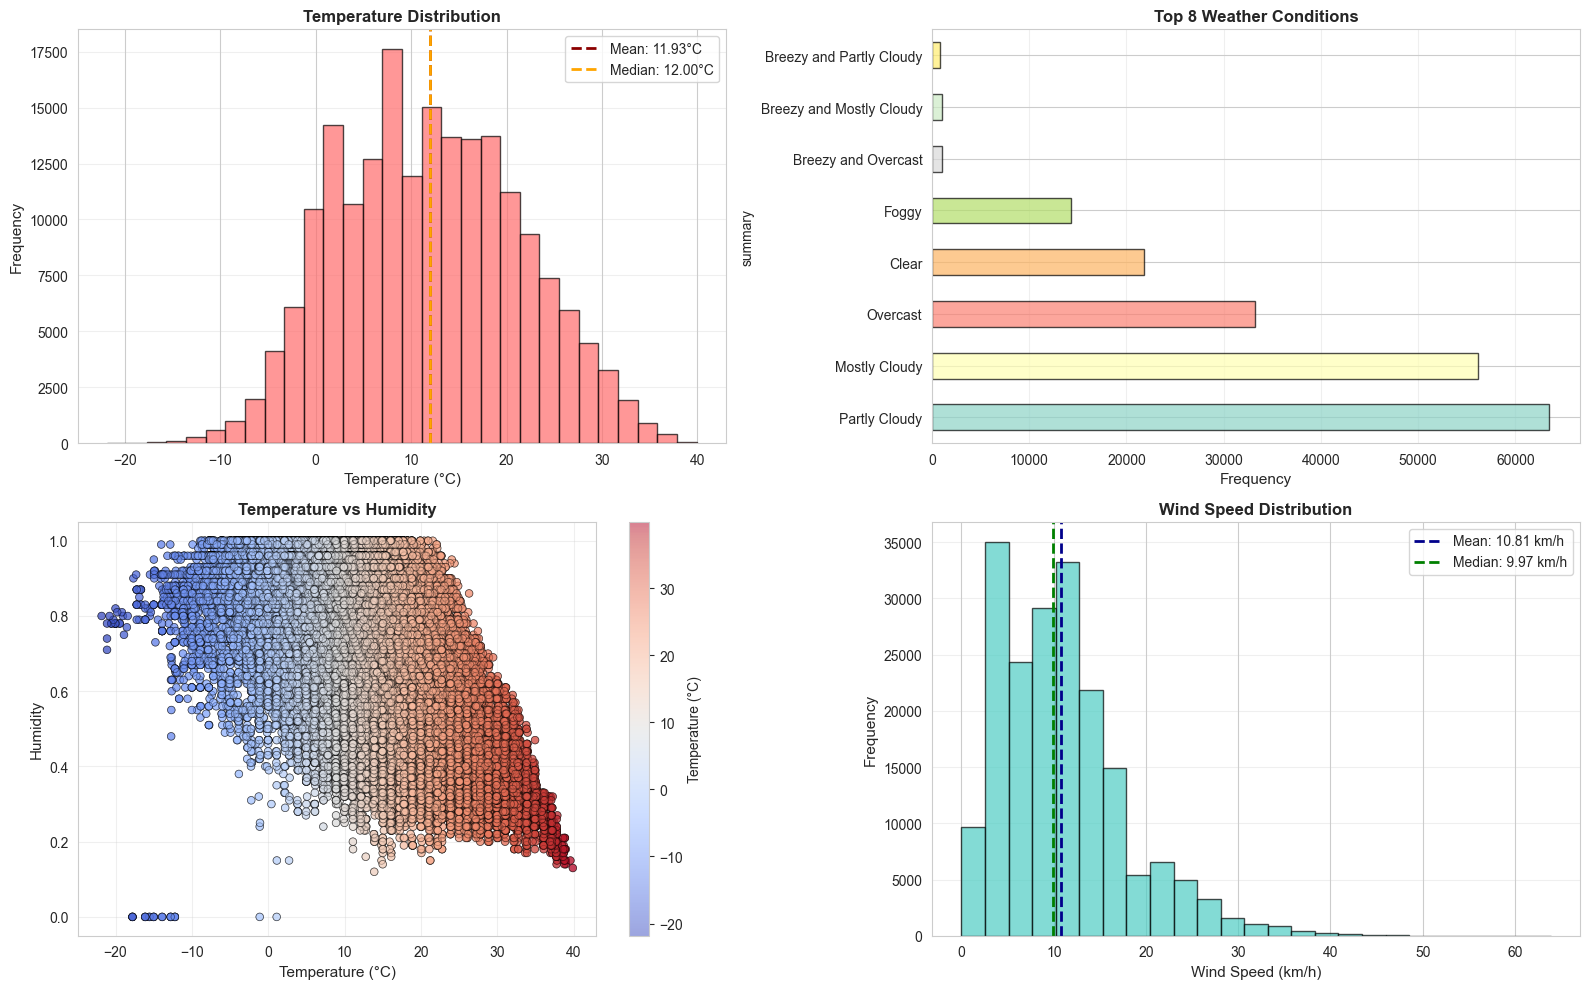

Visualization saved: d:\BDA LAB\Weather Dataset\weather_analysis.png


In [10]:
# Step 5: Data Visualization
print("\n" + "=" * 70)
print("STEP 5: VISUALIZATION OF WEATHER DATA")
print("=" * 70)

weather_all_df = pd.read_sql_query("SELECT * FROM weather", conn)

for col in ['temperature', 'apparent_temperature', 'humidity', 'wind_speed', 'wind_bearing', 'visibility', 'cloud_cover', 'pressure']:
    weather_all_df[col] = pd.to_numeric(weather_all_df[col], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
temp_data = weather_all_df['temperature'].dropna()
ax.hist(temp_data, bins=30, color='#FF6B6B', edgecolor='black', alpha=0.7)
ax.axvline(temp_data.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {temp_data.mean():.2f}°C')
ax.axvline(temp_data.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {temp_data.median():.2f}°C')
ax.set_title('Temperature Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[0, 1]
summary_counts = weather_all_df['summary'].value_counts().head(8)
colors = plt.cm.Set3(np.linspace(0, 1, len(summary_counts)))
summary_counts.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.7)
ax.set_title('Top 8 Weather Conditions', fontsize=12, fontweight='bold')
ax.set_xlabel('Frequency', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

ax = axes[1, 0]
humidity_data = weather_all_df['humidity'].dropna()
scatter = ax.scatter(temp_data, humidity_data, alpha=0.5, c=temp_data, cmap='coolwarm', s=30, edgecolor='black', linewidth=0.5)
ax.set_title('Temperature vs Humidity', fontsize=12, fontweight='bold')
ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_ylabel('Humidity', fontsize=11)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Temperature (°C)', fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
wind_data = weather_all_df['wind_speed'].dropna()
ax.hist(wind_data, bins=25, color='#4ECDC4', edgecolor='black', alpha=0.7)
ax.axvline(wind_data.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Mean: {wind_data.mean():.2f} km/h')
ax.axvline(wind_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {wind_data.median():.2f} km/h')
ax.set_title('Wind Speed Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Wind Speed (km/h)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
visualization_file = os.path.join(os.getcwd(), 'weather_analysis.png')
plt.savefig(visualization_file, dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualization saved: {visualization_file}")

In [11]:
# Step 6: Data Export and Detailed Reports
print("\n" + "=" * 70)
print("STEP 6: EXPORT AND GENERATE REPORTS")
print("=" * 70)

summary_export_file = os.path.join(os.getcwd(), 'weather_summary_stats.csv')
precip_export_file = os.path.join(os.getcwd(), 'precipitation_analysis.csv')
extreme_file = os.path.join(os.getcwd(), 'extreme_temperatures.csv')

summary_stats_df.to_csv(summary_export_file, index=False)
precip_stats_df.to_csv(precip_export_file, index=False)
extreme_temps_df = pd.concat([max_temp_df, min_temp_df], ignore_index=True)
extreme_temps_df.to_csv(extreme_file, index=False)

print("Exported files:")
print(f"  - {summary_export_file}")
print(f"  - {precip_export_file}")
print(f"  - {extreme_file}")

print("Key weather report:")
print(f"  Total records: {len(weather_all_df)}")
print(f"  Unique weather conditions: {weather_all_df['summary'].nunique()}")
print(f"  Avg temperature: {weather_all_df['temperature'].mean():.2f}°C")
print(f"  Avg humidity: {weather_all_df['humidity'].mean():.4f}")
print(f"  Avg wind speed: {weather_all_df['wind_speed'].mean():.2f} km/h")
print("Top 5 weather conditions:")
print(summary_stats_df[['summary', 'frequency']].head().to_string(index=False))


STEP 6: EXPORT AND GENERATE REPORTS
Exported files:
  - d:\BDA LAB\Weather Dataset\weather_summary_stats.csv
  - d:\BDA LAB\Weather Dataset\precipitation_analysis.csv
  - d:\BDA LAB\Weather Dataset\extreme_temperatures.csv
Key weather report:
  Total records: 192906
  Unique weather conditions: 27
  Avg temperature: 11.93°C
  Avg humidity: 0.7349
  Avg wind speed: 10.81 km/h
Top 5 weather conditions:
      summary  frequency
Partly Cloudy      63466
Mostly Cloudy      56188
     Overcast      33194
        Clear      21780
        Foggy      14296


In [12]:
# Step 7: Close Database Connection
print("\n" + "=" * 70)
print("STEP 7: CLEANUP AND DATABASE CLOSURE")
print("=" * 70)

conn.close()
print("Database connection closed successfully")
print("All tasks completed successfully!")


STEP 7: CLEANUP AND DATABASE CLOSURE
Database connection closed successfully
All tasks completed successfully!
